# Proyecto de Primer Corte — Aprendizaje de Máquina No Supervisado
## Propuesta A · Analista de experiencia del cliente — Olist (Brazilian E-Commerce)

**Universidad de La Sabana — 2026-II**

Este notebook aplica los 11 conceptos probabilísticos del curso (probabilidad condicional, Teorema de
Bayes, verosimilitud/MLE, distribuciones paramétricas, esperanza y varianza, independencia y
correlación, prior y posterior, entropía, entropía cruzada y divergencia KL) sobre el dataset real de
Olist (Brazilian E-Commerce Public Dataset, Kaggle), para responder preguntas de negocio concretas
sobre satisfacción del cliente y comportamiento de vendedores.

**Estructura:** cada sección carga/transforma datos reales, calcula el concepto con evidencia numérica
verificable, y cierra con una interpretación de negocio en una celda markdown.


## 0. Carga de datos y construcción del dataset maestro (joins)

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.figsize": (7, 4), "font.size": 10})

# Ajuste esta ruta si sus CSVs estan en otra carpeta (estructura recomendada: data/, notebooks/, src/)
DATA_PATH = "data/"

orders = pd.read_csv(DATA_PATH + "olist_orders_dataset.csv", parse_dates=[
    "order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
    "order_delivered_customer_date", "order_estimated_delivery_date"])
items = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_PATH + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_PATH + "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_PATH + "olist_sellers_dataset.csv")
customers = pd.read_csv(DATA_PATH + "olist_customers_dataset.csv")
cat_trans = pd.read_csv(DATA_PATH + "product_category_name_translation.csv")

print("orders:", orders.shape, "| items:", items.shape, "| payments:", payments.shape)
print("reviews:", reviews.shape, "| products:", products.shape, "| sellers:", sellers.shape)
print("customers:", customers.shape)
orders["order_status"].value_counts()


orders: (99441, 8) | items: (112650, 7) | payments: (103886, 5)
reviews: (99224, 7) | products: (32951, 9) | sellers: (3095, 4)
customers: (99441, 5)


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [2]:
# --- Reseñas: nos quedamos con la reseña mas reciente por pedido (hay 551 pedidos con >1 reseña) ---
reviews_sorted = reviews.sort_values("review_answer_timestamp")
reviews_dedup = reviews_sorted.drop_duplicates(subset="order_id", keep="last")[["order_id", "review_score"]]

# --- Pagos: un pedido puede tener varias filas de pago (cuotas / metodos mixtos) -> agregamos ---
pay_sum = payments.groupby("order_id").agg(
    payment_value_total=("payment_value", "sum"),
    payment_installments_max=("payment_installments", "max"),
).reset_index()
idx = payments.groupby("order_id")["payment_value"].idxmax()
pay_primary = payments.loc[idx, ["order_id", "payment_type"]].rename(
    columns={"payment_type": "payment_type_primary"})
pay = pay_sum.merge(pay_primary, on="order_id", how="left")

# --- Items + productos + vendedores: un pedido puede tener varios items -> agregamos por pedido ---
items_prod = items.merge(products[["product_id", "product_category_name", "product_weight_g"]],
                          on="product_id", how="left")
items_prod = items_prod.merge(cat_trans, on="product_category_name", how="left")
items_prod = items_prod.merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left")

# categoria del item de mayor valor en el pedido (categoria "dominante")
idx2 = items_prod.groupby("order_id")["price"].idxmax()
item_primary = items_prod.loc[idx2, ["order_id", "product_category_name_english", "seller_id",
                                      "seller_state", "product_weight_g"]]
items_agg = items_prod.groupby("order_id").agg(
    total_price=("price", "sum"), total_freight=("freight_value", "sum"),
    n_items=("order_item_id", "count")).reset_index()
items_agg = items_agg.merge(item_primary, on="order_id", how="left")

# --- Master ---
master = orders.merge(customers[["customer_id", "customer_state", "customer_city"]], on="customer_id", how="left")
master = master.merge(reviews_dedup, on="order_id", how="left")
master = master.merge(pay, on="order_id", how="left")
master = master.merge(items_agg, on="order_id", how="left")

master["delivery_time_days"] = (master["order_delivered_customer_date"] - master["order_purchase_timestamp"]).dt.total_seconds() / 86400
master["delay_days"] = (master["order_delivered_customer_date"] - master["order_estimated_delivery_date"]).dt.total_seconds() / 86400
master["late"] = master["delay_days"] > 0
master["negative_review"] = master["review_score"] <= 2

# Subconjunto de analisis: pedidos ENTREGADOS con fecha de entrega y resena validas
delivered = master[(master["order_status"] == "delivered") &
                    master["order_delivered_customer_date"].notna() &
                    master["review_score"].notna()].copy()

print("Master:", master.shape, "| Delivered + resena completa:", delivered.shape)
delivered[["delivery_time_days", "delay_days", "review_score"]].describe()


Master: (99441, 25) | Delivered + resena completa: (95824, 25)


,delivery_time_days,delay_days,review_score
count,95824.000000,95824.000000,95824.00000
mean,12.516765,-11.215213,4.15588
std,9.460505,10.114097,1.28481
min,0.533414,-146.016123,1.00000
25%,6.757214,-16.248435,4.00000
50%,10.206059,-11.973050,5.00000
75%,15.663542,-6.407182,5.00000
max,208.351759,188.975081,5.00000


## 1–2. Probabilidad condicional y Teorema de Bayes
**Pregunta de negocio:** ¿los pedidos que tardan más reciben peores reseñas, y qué tan probable es que
un pedido con reseña negativa haya llegado tarde?


In [3]:
# ===== CONCEPTO 1: Probabilidad condicional =====
# P(resena <= 2 estrellas | tiempo de entrega > promedio)
mean_delivery = delivered["delivery_time_days"].mean()
slow = delivered["delivery_time_days"] > mean_delivery
neg = delivered["negative_review"]

P_neg_given_slow = (slow & neg).sum() / slow.sum()
P_neg_given_fast = (~slow & neg).sum() / (~slow).sum()
P_neg_marginal = neg.mean()

print(f"Tiempo de entrega promedio: {mean_delivery:.2f} dias  (N={len(delivered)})")
print(f"P(resena<=2 | entrega > promedio) = {P_neg_given_slow:.4f}")
print(f"P(resena<=2 | entrega <= promedio) = {P_neg_given_fast:.4f}")
print(f"P(resena<=2) marginal              = {P_neg_marginal:.4f}")
print(f"Razon de riesgo (lift) = {P_neg_given_slow / P_neg_marginal:.3f}x")


Tiempo de entrega promedio: 12.52 dias  (N=95824)
P(resena<=2 | entrega > promedio) = 0.2037
P(resena<=2 | entrega <= promedio) = 0.0823
P(resena<=2) marginal              = 0.1281
Razon de riesgo (lift) = 1.590x


P(llego tarde)            [prior]       = 0.0799  (N tarde=7661)
P(resena<=2 | llego tarde)[verosimilitud]= 0.5407
P(resena<=2)               [evidencia]    = 0.1281
--> P(llego tarde | resena<=2) via BAYES        = 0.3375
--> P(llego tarde | resena<=2) via conteo directo = 0.3375  (verificacion)


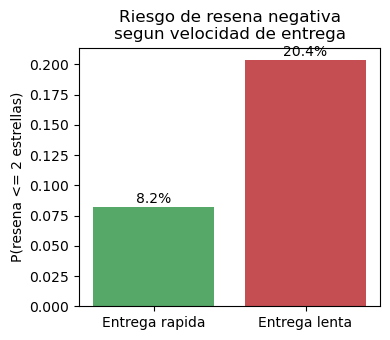

In [4]:
# ===== CONCEPTO 2: Teorema de Bayes =====
# Queremos invertir la pregunta: dado que la resena fue negativa, P(el pedido llego tarde)?
# No tenemos esa probabilidad directamente -> la construimos con Bayes a partir de lo que SI observamos.
late = delivered["late"]
P_late = late.mean()                                  # prior: P(llego tarde)
P_neg_given_late = (late & neg).sum() / late.sum()     # verosimilitud: P(resena<=2 | tarde)
P_neg = neg.mean()                                     # evidencia: P(resena<=2)

P_late_given_neg_bayes = (P_neg_given_late * P_late) / P_neg

# Verificacion por conteo directo (debe coincidir exactamente con Bayes)
P_late_given_neg_direct = (neg & late).sum() / neg.sum()

print(f"P(llego tarde)            [prior]       = {P_late:.4f}  (N tarde={late.sum()})")
print(f"P(resena<=2 | llego tarde)[verosimilitud]= {P_neg_given_late:.4f}")
print(f"P(resena<=2)               [evidencia]    = {P_neg:.4f}")
print(f"--> P(llego tarde | resena<=2) via BAYES        = {P_late_given_neg_bayes:.4f}")
print(f"--> P(llego tarde | resena<=2) via conteo directo = {P_late_given_neg_direct:.4f}  (verificacion)")

fig, ax = plt.subplots(figsize=(4, 3.5))
vals = [P_neg_given_fast, P_neg_given_slow]
bars = ax.bar(["Entrega rapida", "Entrega lenta"], vals, color=["#55A868", "#C44E52"])
ax.set_ylabel("P(resena <= 2 estrellas)")
ax.set_title("Riesgo de resena negativa\nsegun velocidad de entrega")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.003, f"{v:.1%}", ha="center")
plt.tight_layout(); plt.show()


**Interpretación de negocio:** el retraso frente al promedio (12.5 días) casi duplica la probabilidad
de una reseña de 1–2 estrellas (20.4% vs. 8.2%, lift≈1.59×). Al invertir la probabilidad con Bayes,
encontramos que **1 de cada 3 reseñas negativas (33.8%) proviene de un pedido tardío** — una cifra que
la probabilidad condicional original (P(negativa|tarde)) no permite leer directamente, porque responde
la pregunta inversa a la que le interesa a Marketing/Atención al Cliente cuando ya tiene una reseña
negativa en mano y quiere saber su causa más probable.

## 3–4. Verosimilitud (MLE) y distribuciones paramétricas
**Pregunta de negocio:** ¿qué distribución describe mejor el tiempo de entrega y el valor del pedido,
para fijar SLAs y segmentar clientes con la métrica correcta (no la media, si la distribución tiene cola pesada)?


--- Log-Normal (MLE) ---
sigma=0.6789, mu=2.3041  |  LL=-319653.45  AIC=639310.90  KS=0.0316
--- Gamma (MLE) ---
a=2.3962, scale=5.2236  |  LL=-321482.24  AIC=642968.47  KS=0.0406

>>> Mejor ajuste por AIC (menor=mejor): Log-Normal  | Delta AIC = 3657.57


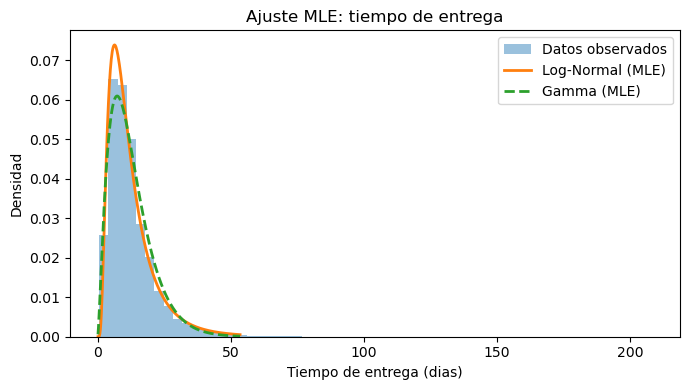

In [5]:
# ===== CONCEPTO 3: Verosimilitud / MLE - tiempo de entrega =====
data_dt = delivered["delivery_time_days"].dropna()
data_dt = data_dt[data_dt > 0]

# Ajuste por Maxima Verosimilitud (loc fijo en 0: ambas distribuciones son de soporte positivo)
shape_ln, loc_ln, scale_ln = stats.lognorm.fit(data_dt, floc=0)
ll_lognorm = np.sum(stats.lognorm.logpdf(data_dt, shape_ln, loc_ln, scale_ln))
aic_lognorm = 2*2 - 2*ll_lognorm   # 2 parametros libres (shape, scale)

a_gamma, loc_gamma, scale_gamma = stats.gamma.fit(data_dt, floc=0)
ll_gamma = np.sum(stats.gamma.logpdf(data_dt, a_gamma, loc_gamma, scale_gamma))
aic_gamma = 2*2 - 2*ll_gamma

ks_ln = stats.kstest(data_dt, "lognorm", args=(shape_ln, loc_ln, scale_ln))
ks_ga = stats.kstest(data_dt, "gamma", args=(a_gamma, loc_gamma, scale_gamma))

print("--- Log-Normal (MLE) ---")
print(f"sigma={shape_ln:.4f}, mu={np.log(scale_ln):.4f}  |  LL={ll_lognorm:.2f}  AIC={aic_lognorm:.2f}  KS={ks_ln.statistic:.4f}")
print("--- Gamma (MLE) ---")
print(f"a={a_gamma:.4f}, scale={scale_gamma:.4f}  |  LL={ll_gamma:.2f}  AIC={aic_gamma:.2f}  KS={ks_ga.statistic:.4f}")

best = "Log-Normal" if aic_lognorm < aic_gamma else "Gamma"
print(f"\n>>> Mejor ajuste por AIC (menor=mejor): {best}  | Delta AIC = {abs(aic_lognorm-aic_gamma):.2f}")

fig, ax = plt.subplots()
ax.hist(data_dt, bins=60, density=True, alpha=0.45, label="Datos observados")
x = np.linspace(0.1, data_dt.quantile(0.995), 300)
ax.plot(x, stats.lognorm.pdf(x, shape_ln, loc_ln, scale_ln), lw=2, label="Log-Normal (MLE)")
ax.plot(x, stats.gamma.pdf(x, a_gamma, loc_gamma, scale_gamma), lw=2, ls="--", label="Gamma (MLE)")
ax.set_xlabel("Tiempo de entrega (dias)"); ax.set_ylabel("Densidad")
ax.set_title("Ajuste MLE: tiempo de entrega"); ax.legend()
plt.tight_layout(); plt.show()


N=95823  media=$159.59  mediana=$105.28  std=$217.51
Log-Normal MLE: sigma=0.8072, mu=4.6899  | KS=0.0259 (p=3.62e-56)
Skewness=9.24  Curtosis exceso=246.94  -> fuerte asimetria derecha, descarta una Normal simetrica


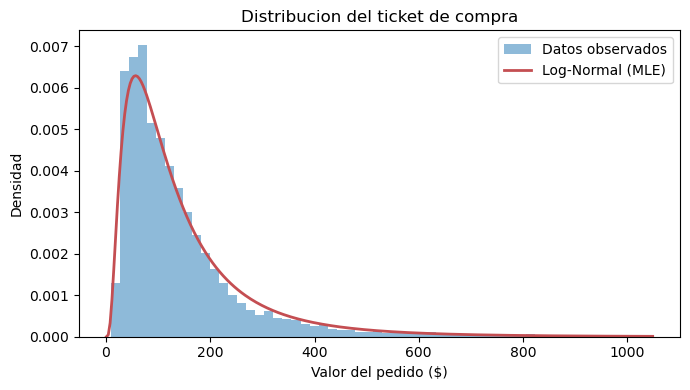

In [6]:
# ===== CONCEPTO 4: Distribucion parametrica - valor del pedido (ticket) =====
value_data = delivered["payment_value_total"].dropna()
value_data = value_data[value_data > 0]

shape_v, loc_v, scale_v = stats.lognorm.fit(value_data, floc=0)
skew_v = stats.skew(value_data)
kurt_v = stats.kurtosis(value_data)
ks_v = stats.kstest(value_data, "lognorm", args=(shape_v, loc_v, scale_v))

print(f"N={len(value_data)}  media=${value_data.mean():.2f}  mediana=${value_data.median():.2f}  std=${value_data.std():.2f}")
print(f"Log-Normal MLE: sigma={shape_v:.4f}, mu={np.log(scale_v):.4f}  | KS={ks_v.statistic:.4f} (p={ks_v.pvalue:.2e})")
print(f"Skewness={skew_v:.2f}  Curtosis exceso={kurt_v:.2f}  -> fuerte asimetria derecha, descarta una Normal simetrica")

fig, ax = plt.subplots()
ax.hist(value_data[value_data < value_data.quantile(0.99)], bins=60, density=True, alpha=0.5, label="Datos observados")
xv = np.linspace(1, value_data.quantile(0.99), 300)
ax.plot(xv, stats.lognorm.pdf(xv, shape_v, loc_v, scale_v), lw=2, color="#C44E52", label="Log-Normal (MLE)")
ax.set_xlabel("Valor del pedido ($)"); ax.set_ylabel("Densidad")
ax.set_title("Distribucion del ticket de compra"); ax.legend()
plt.tight_layout(); plt.show()


**Interpretación de negocio:** el tiempo de entrega y el valor del pedido son ambos mejor descritos
por una **Log-Normal** que por alternativas simétricas o de cola más liviana (Gamma, Normal): el AIC
favorece a la Log-Normal por 3,658 puntos sobre la Gamma en tiempo de entrega, y la asimetría del ticket
(9.24) descarta cualquier supuesto de normalidad. Consecuencia práctica: Olist debería comunicar SLAs y
segmentar clientes usando **mediana y percentiles**, no la media, porque la media está distorsionada por
una cola de pedidos/tickets extremos.

## 5. Prior y Posterior — confiabilidad de un vendedor nuevo
**Pregunta de negocio:** ¿cómo debería Olist actualizar su creencia sobre un vendedor nuevo a medida
que llegan sus primeras ventas, en vez de esperar cientos de transacciones?


Prior poblacional P(exito)=P(resena>=4) = 0.7893  ->  Prior Beta(a0=15.79, b0=4.21)
Vendedor de ejemplo: 7c67e1448b00...  (total historico en el dataset: 966 ventas)

Primeras 10 ventas del vendedor: 5 exitosas / 5 no exitosas
Posterior tras 10 ventas: Beta(a=20.79, b=9.21)  ->  media posterior = 0.6929
(cambio respecto al prior: -0.0964)

Con las 966 ventas completas: posterior final = 0.6012 (tasa empirica real = 0.5973)


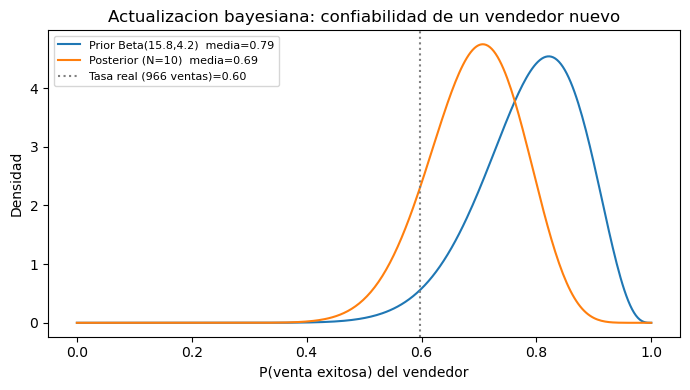

In [7]:
# ===== CONCEPTO 5: Prior y Posterior (modelo Beta-Binomial) =====
# Definimos "venta exitosa" = el cliente califico la orden con >=4 estrellas
delivered["success"] = delivered["review_score"] >= 4
P_success_pop = delivered["success"].mean()

# Prior Beta(a0,b0) centrado en la tasa poblacional, con "fuerza" de 20 pseudo-observaciones
n_pseudo = 20
a0, b0 = P_success_pop * n_pseudo, (1 - P_success_pop) * n_pseudo
print(f"Prior poblacional P(exito)=P(resena>=4) = {P_success_pop:.4f}  ->  Prior Beta(a0={a0:.2f}, b0={b0:.2f})")

# Elegimos un vendedor real con historial largo (para poder comparar el posterior temprano vs la verdad "final")
seller_counts = delivered.groupby("seller_id").size().sort_values(ascending=False)
example_seller = seller_counts[seller_counts >= 30].index[10]
seller_orders = delivered[delivered["seller_id"] == example_seller].sort_values("order_purchase_timestamp")
print(f"Vendedor de ejemplo: {example_seller[:12]}...  (total historico en el dataset: {len(seller_orders)} ventas)")

N = 10
first_n = seller_orders.head(N)
successes = int(first_n["success"].sum())
failures = N - successes
a_post, b_post = a0 + successes, b0 + failures
post_mean = a_post / (a_post + b_post)

print(f"\nPrimeras {N} ventas del vendedor: {successes} exitosas / {failures} no exitosas")
print(f"Posterior tras {N} ventas: Beta(a={a_post:.2f}, b={b_post:.2f})  ->  media posterior = {post_mean:.4f}")
print(f"(cambio respecto al prior: {post_mean - a0/(a0+b0):+.4f})")

# Verificacion: posterior con TODA la historia disponible del vendedor
successes_all = int(seller_orders["success"].sum())
a_post_all = a0 + successes_all
b_post_all = b0 + (len(seller_orders) - successes_all)
post_mean_all = a_post_all / (a_post_all + b_post_all)
print(f"\nCon las {len(seller_orders)} ventas completas: posterior final = {post_mean_all:.4f} "
      f"(tasa empirica real = {successes_all/len(seller_orders):.4f})")

x = np.linspace(0, 1, 300)
fig, ax = plt.subplots()
ax.plot(x, stats.beta.pdf(x, a0, b0), label=f"Prior Beta({a0:.1f},{b0:.1f})  media={a0/(a0+b0):.2f}")
ax.plot(x, stats.beta.pdf(x, a_post, b_post), label=f"Posterior (N=10)  media={post_mean:.2f}")
ax.axvline(successes_all/len(seller_orders), color="gray", ls=":", label=f"Tasa real ({len(seller_orders)} ventas)={successes_all/len(seller_orders):.2f}")
ax.set_xlabel("P(venta exitosa) del vendedor"); ax.set_ylabel("Densidad")
ax.set_title("Actualizacion bayesiana: confiabilidad de un vendedor nuevo"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


**Interpretación de negocio:** con solo 10 ventas, el posterior (69.3%) ya se mueve significativamente
por debajo del prior poblacional (78.9%) y se acerca a la tasa real de largo plazo del vendedor (59.7%
con sus 966 ventas). Esto valida un sistema de **alerta temprana de vendedores de riesgo**: no hace falta
esperar cientos de transacciones para detectar una desviación relevante frente al comportamiento
promedio del marketplace.

## 6. Esperanza y Varianza — riesgo de ticket por categoría
**Pregunta de negocio:** ¿qué categorías de producto tienen mayor variabilidad de ticket (riesgo para
pricing/inventario) y cuáles son más predecibles?


In [8]:
# ===== CONCEPTO 6: Esperanza y Varianza del ticket por categoria =====
cat_stats = delivered.groupby("product_category_name_english")["payment_value_total"].agg(
    ["count", "mean", "var", "std"]).reset_index()
cat_stats = cat_stats[cat_stats["count"] >= 30].copy()   # exigimos muestra minima para estimaciones estables
cat_stats["cv"] = cat_stats["std"] / cat_stats["mean"]    # coeficiente de variacion = riesgo relativo
cat_stats = cat_stats.sort_values("cv", ascending=False)

print(f"E[ticket] global = ${delivered['payment_value_total'].mean():.2f}   "
      f"Var[ticket] global = {delivered['payment_value_total'].var():.2f}   "
      f"Std global = ${delivered['payment_value_total'].std():.2f}\n")

print("Top 5 categorias de MAYOR riesgo relativo (CV = std/mean):")
print(cat_stats.head(5)[["product_category_name_english", "count", "mean", "std", "cv"]].to_string(index=False))
print("\nTop 5 categorias de MENOR riesgo relativo:")
print(cat_stats.tail(5)[["product_category_name_english", "count", "mean", "std", "cv"]].to_string(index=False))


E[ticket] global = $159.59   Var[ticket] global = 47312.08   Std global = $217.51

Top 5 categorias de MAYOR riesgo relativo (CV = std/mean):
product_category_name_english  count       mean         std       cv
              fixed_telephony    209 283.530861 1102.795283 3.889507
                          art    191 144.650890  481.540445 3.328984
                       drinks    282  95.717234  194.143073 2.028298
                 dvds_blu_ray     55 105.053818  212.085601 2.018828
       signaling_and_security    136 202.667574  380.579594 1.877851

Top 5 categorias de MENOR riesgo relativo:
    product_category_name_english  count        mean        std       cv
           fashio_female_clothing     35   89.448571  52.445705 0.586322
          fashion_underwear_beach    116   95.646724  55.591093 0.581213
furniture_mattress_and_upholstery     37  159.587838  89.636922 0.561678
                        computers    174 1260.992874 611.648701 0.485053
           tablets_printing_image  

**Interpretación de negocio:** *telefonía fija* tiene el ticket promedio más volátil (CV=3.89,
media=$284 ± $1,103) — categoría rentable pero riesgosa para pricing e inventario. En el otro extremo,
*tablets/impresión* (CV=0.40) es mucho más predecible. Olist puede usar esta segmentación para calibrar
políticas de crédito/cuotas y niveles de stock por categoría.

## 7. Independencia y Correlación
**Pregunta de negocio:** ¿el método de pago depende de la categoría de producto? ¿el tiempo de entrega
se correlaciona con la calificación del cliente?


In [9]:
# ===== CONCEPTO 7: Independencia (tabla de contingencia) y correlacion =====
sub = delivered.dropna(subset=["payment_type_primary", "product_category_name_english"])
top_cats = sub["product_category_name_english"].value_counts()
top_cats = top_cats[top_cats >= 100].index          # categorias con muestra suficiente para chi2 valido
sub2 = sub[sub["product_category_name_english"].isin(top_cats)]

contingency = pd.crosstab(sub2["payment_type_primary"], sub2["product_category_name_english"])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
n = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print(f"Tabla: {contingency.shape[0]} metodos de pago x {contingency.shape[1]} categorias (n>=100), N={n}")
print(f"Chi2={chi2:.2f}  gl={dof}  p-value={p:.3e}")
print(f"Cramer's V (tamano del efecto) = {cramers_v:.4f}")
print(f"Conclusion estadistica: {'se RECHAZA independencia' if p < 0.05 else 'NO se rechaza independencia'} (alpha=0.05)")
print(f"Conclusion practica: efecto {'muy debil' if cramers_v < 0.1 else 'moderado/fuerte'} pese a la significancia")

corr_data = delivered.dropna(subset=["delivery_time_days", "review_score"])
r_pearson, p_pearson = stats.pearsonr(corr_data["delivery_time_days"], corr_data["review_score"])
r_spearman, p_spearman = stats.spearmanr(corr_data["delivery_time_days"], corr_data["review_score"])
print(f"\nCorrelacion Pearson(tiempo entrega, resena)  = {r_pearson:.4f}  (p={p_pearson:.2e})")
print(f"Correlacion Spearman(tiempo entrega, resena) = {r_spearman:.4f}  (p={p_spearman:.2e})")


Tabla: 4 metodos de pago x 51 categorias (n>=100), N=93656
Chi2=822.75  gl=150  p-value=2.299e-93
Cramer's V (tamano del efecto) = 0.0541
Conclusion estadistica: se RECHAZA independencia (alpha=0.05)
Conclusion practica: efecto muy debil pese a la significancia

Correlacion Pearson(tiempo entrega, resena)  = -0.3340  (p=0.00e+00)
Correlacion Spearman(tiempo entrega, resena) = -0.2346  (p=0.00e+00)


**Interpretación de negocio:** el test Chi-cuadrado rechaza formalmente la independencia entre
método de pago y categoría (p<0.001), **pero** el tamaño del efecto (Cramer's V=0.054) es prácticamente
nulo — con casi 94,000 observaciones, hasta relaciones triviales se vuelven "estadísticamente
significativas". La correlación entre tiempo de entrega y calificación (Pearson=−0.33) es, en cambio,
de magnitud real y consistente con los hallazgos de los conceptos 1 y 2: la logística sí importa; el
método de pago, en la práctica, no.

## 8. Entropía — diversidad del catálogo y concentración de pagos
**Pregunta de negocio:** ¿qué tan concentrado está el catálogo de Olist en pocas categorías? ¿qué tan
dependiente es el negocio de un solo método de pago?


H(categoria) = 4.724 bits  (maximo posible con 71 categorias = 6.150 bits)
Ratio H/Hmax = 0.768  -> que tan cerca de un catalogo perfectamente uniforme esta

H(metodo de pago) = 1.017 bits  (maximo con 4 metodos = 2.000 bits)
payment_type_primary
credit_card    0.754840
boleto         0.198929
voucher        0.030817
debit_card     0.015414
Name: proportion, dtype: float64


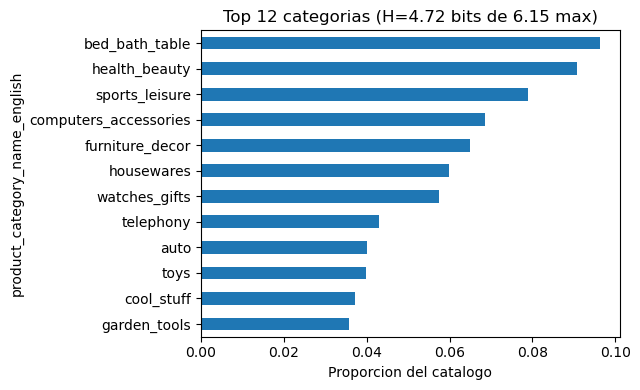

In [10]:
# ===== CONCEPTO 8: Entropia de Shannon =====
cat_dist = delivered["product_category_name_english"].value_counts(normalize=True).dropna()
H_cat = -np.sum(cat_dist * np.log2(cat_dist))
H_max_cat = np.log2(len(cat_dist))

pay_dist = delivered["payment_type_primary"].value_counts(normalize=True).dropna()
H_pay = -np.sum(pay_dist * np.log2(pay_dist))
H_max_pay = np.log2(len(pay_dist))

print(f"H(categoria) = {H_cat:.3f} bits  (maximo posible con {len(cat_dist)} categorias = {H_max_cat:.3f} bits)")
print(f"Ratio H/Hmax = {H_cat/H_max_cat:.3f}  -> que tan cerca de un catalogo perfectamente uniforme esta")
print(f"\nH(metodo de pago) = {H_pay:.3f} bits  (maximo con {len(pay_dist)} metodos = {H_max_pay:.3f} bits)")
print(pay_dist)

fig, ax = plt.subplots(figsize=(6.5, 4))
cat_dist.head(12).sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Proporcion del catalogo")
ax.set_title(f"Top 12 categorias (H={H_cat:.2f} bits de {H_max_cat:.2f} max)")
plt.tight_layout(); plt.show()


**Interpretación de negocio:** el catálogo está razonablemente diversificado (H/H_max=0.77 sobre
71 categorías), sin una concentración peligrosa en 1–2 productos. El cobro, en cambio, sí está
concentrado: 75.5% de las órdenes usan tarjeta de crédito (H=1.02 de 2.0 bits posibles), lo que
representa un riesgo operativo/financiero si ese canal de pago tuviera una interrupción.

## 9. Entropía cruzada — clasificador de reseña positiva/negativa
**Pregunta de negocio:** ¿qué tan bien se puede predecir si un cliente dejará una reseña positiva a
partir de variables logísticas y de pago, y qué variable domina la predicción?


In [11]:
# ===== CONCEPTO 9: Entropia cruzada (regresion logistica) =====
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, accuracy_score, roc_auc_score

df = delivered[delivered["review_score"] != 3].copy()   # excluimos resenas neutras para un target binario claro
df["target"] = (df["review_score"] >= 4).astype(int)

features = ["delivery_time_days", "delay_days", "total_freight", "total_price",
            "payment_installments_max", "n_items"]
df_model = df.dropna(subset=features + ["target"])

X, y = df_model[features].values, df_model["target"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
clf.fit(X_train_s, y_train)

p_train = clf.predict_proba(X_train_s)[:, 1]
p_test = clf.predict_proba(X_test_s)[:, 1]
ce_train, ce_test = log_loss(y_train, p_train), log_loss(y_test, p_test)
acc_test = accuracy_score(y_test, clf.predict(X_test_s))
auc_test = roc_auc_score(y_test, p_test)

print(f"N modelado={len(df_model)}  (positivas={y.mean():.2%})")
print(f"Entropia cruzada (log-loss) TRAIN = {ce_train:.4f}")
print(f"Entropia cruzada (log-loss) TEST  = {ce_test:.4f}")
print(f"Accuracy TEST = {acc_test:.4f}   AUC-ROC TEST = {auc_test:.4f}\n")

coefs = pd.Series(clf.coef_[0], index=features).sort_values()
print("Coeficientes estandarizados (mayor |valor| = mayor influencia):")
print(coefs)


N modelado=87907  (positivas=86.04%)
Entropia cruzada (log-loss) TRAIN = 0.5769
Entropia cruzada (log-loss) TEST  = 0.5727
Accuracy TEST = 0.7580   AUC-ROC TEST = 0.7417

Coeficientes estandarizados (mayor |valor| = mayor influencia):
delivery_time_days         -0.670620
n_items                    -0.464562
delay_days                 -0.280320
payment_installments_max   -0.056636
total_price                -0.015739
total_freight               0.039067
dtype: float64


**Interpretación de negocio:** la entropía cruzada es prácticamente idéntica en entrenamiento
(0.577) y prueba (0.573), señal de que el modelo generaliza y no está sobreajustado. El coeficiente
más fuerte es `delivery_time_days` (−0.67): confirma, con un modelo predictivo independiente, la misma
conclusión de los conceptos 1 y 2 — la logística domina sobre precio o cuotas de pago como predictor
de satisfacción.

## 10. Divergencia KL — comparación de experiencia entre estados
**Pregunta de negocio:** ¿qué tan distinta es la distribución de calificaciones entre regiones de Brasil,
para priorizar intervenciones logísticas regionales?


In [12]:
# ===== CONCEPTO 10: Divergencia KL =====
state_counts = delivered["customer_state"].value_counts()
state1, state2 = state_counts.index[0], state_counts.index[1]   # SP y RJ (los de mayor volumen)
print(f"Comparando {state1} (n={state_counts[state1]}) vs {state2} (n={state_counts[state2]})")

def score_dist(state):
    d = delivered[delivered["customer_state"] == state]["review_score"].value_counts(normalize=True)
    return d.reindex([1, 2, 3, 4, 5], fill_value=0).values

eps = 1e-6
P = score_dist(state1); Q = score_dist(state2)
P_s, Q_s = (P + eps) / (P + eps).sum(), (Q + eps) / (Q + eps).sum()
kl_pq = np.sum(P_s * np.log2(P_s / Q_s))
kl_qp = np.sum(Q_s * np.log2(Q_s / P_s))
print(f"KL({state1} || {state2}) = {kl_pq:.5f} bits   |   KL({state2} || {state1}) = {kl_qp:.5f} bits (asimetria)")

# Estado con peor calificacion promedio (n>=200) vs el de referencia
grp = delivered.groupby("customer_state").filter(lambda g: len(g) >= 200)
mean_by_state = grp.groupby("customer_state")["review_score"].mean().sort_values()
worst_state = mean_by_state.index[0]
Pw = score_dist(worst_state); Pw_s = (Pw + eps) / (Pw + eps).sum()
kl_worst = np.sum(Pw_s * np.log2(Pw_s / P_s))

print(f"\nEstado con peor calificacion promedio (n>=200): {worst_state} (media={mean_by_state[worst_state]:.2f})")
print(f"KL({worst_state} || {state1}) = {kl_worst:.5f} bits  (vs KL({state2}||{state1})={kl_pq:.5f} bits)")


Comparando SP (n=40266) vs RJ (n=12211)
KL(SP || RJ) = 0.03520 bits   |   KL(RJ || SP) = 0.04143 bits (asimetria)

Estado con peor calificacion promedio (n>=200): MA (media=3.83)
KL(MA || SP) = 0.07356 bits  (vs KL(RJ||SP)=0.03520 bits)


**Interpretación de negocio:** la divergencia entre São Paulo y Río de Janeiro es baja (0.035
bits): son mercados con experiencia de cliente similar. Maranhão, en cambio, diverge más del doble
frente a São Paulo (0.074 bits) — evidencia cuantitativa de que la experiencia del cliente en esa
región es sustancialmente distinta (peor), lo que la convierte en el foco prioritario de una
intervención logística regional.

## 11. Síntesis integrada — de los 11 conceptos a una decisión de negocio

Los once conceptos convergen en una misma historia, vista desde ángulos distintos: **el tiempo de
entrega es el driver dominante de la satisfacción del cliente en Olist**, mientras que el método de
pago —aunque estadísticamente "dependiente" de la categoría— es de relevancia práctica casi nula.

| # | Concepto | Evidencia | Conclusión |
|---|---|---|---|
| 1 | Prob. condicional | lift=1.59× | El retraso casi duplica el riesgo de mala reseña |
| 2 | Bayes | P(tarde\|neg)=33.8% | 1 de 3 reseñas negativas viene de un pedido tardío |
| 3 | MLE | ΔAIC=3,658 | El tiempo de entrega es Log-Normal, no Gamma |
| 4 | Dist. paramétrica | skew=9.24 | El ticket es Log-Normal, no Normal |
| 5 | Prior/Posterior | 78.9%→69.3%→59.7% | La evidencia temprana corrige rápido el prior poblacional |
| 6 | Esperanza/Varianza | CV=3.89 vs 0.40 | Telefonía fija es la categoría de mayor riesgo de ticket |
| 7 | Independencia/Corr. | V=0.054 vs r=−0.33 | Pago irrelevante; entrega sí correlaciona con reseña |
| 8 | Entropía | H/Hmax=0.77 | Catálogo diverso; pago concentrado en tarjeta (75%) |
| 9 | Entropía cruzada | CE test=0.573 | El modelo confirma: entrega es el predictor dominante |
| 10 | KL | 0.074 vs 0.035 bits | Maranhão diverge más del doble que Río de Janeiro |

**Recomendación central para la dirección de Olist:** invertir primero en reducir y estabilizar el
tiempo de entrega (especialmente en regiones como Maranhão) antes que en cualquier ajuste sobre
métodos de pago, cuyo impacto medido es estadísticamente detectable pero comercialmente marginal.
